# Regresión — Combined Cycle Power Plant (CCPP)
**Dataset:** [Combined Cycle Power Plant](https://www.kaggle.com/datasets/shivendraverma/combined-cycle-power-plant)  
**Variable a predecir (Y):** `PE` — Producción neta de energía eléctrica por hora (MW)  
**Variables predictoras (X):** AT (Temperatura), V (Vacío de escape), AP (Presión atmosférica), RH (Humedad relativa)

## 1. Importar dataset

In [1]:
import pandas as pd

df = pd.read_csv('CCPP.csv')
df.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.27
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


## 2. Verificación de nulos

In [2]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

## 3. Tipos de dato (verificar si hay texto)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB


**Resultado:** No hay valores nulos ni columnas de tipo texto. Todas las variables son `float64`, por lo tanto no se requiere conversión ni tratamiento de nulos.

## 4. Escalado

In [4]:
from sklearn.preprocessing import StandardScaler

X = df[['AT', 'V', 'AP', 'RH']]
y = df['PE']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 5. Selección de características
Se aplicará 1 metodo para determinar cuáles variables de X son las más relevantes para predecir PE.

### Matriz de correlación

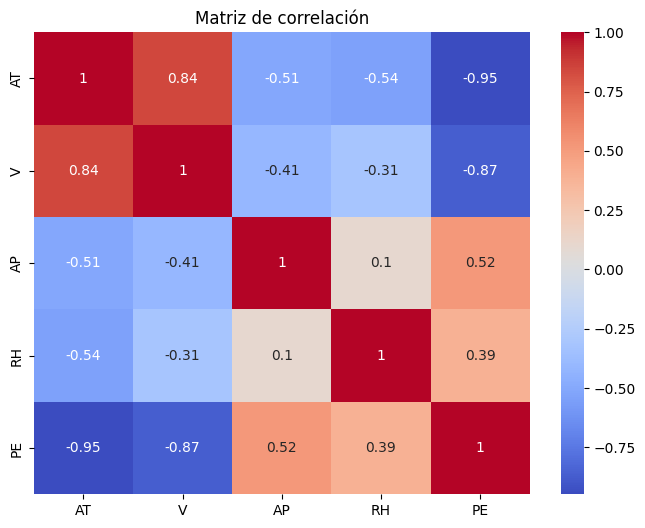

AT    0.948128
V     0.869780
AP    0.518429
RH    0.389794
Name: PE, dtype: float64


In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

df_corr = X.copy()
df_corr['PE'] = y.values

correlation_matrix = df_corr.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Matriz de correlación')
plt.show()

correlaciones = abs(correlation_matrix['PE'].drop('PE'))
sorted_corr = correlaciones.sort_values(ascending=False)
print(sorted_corr)

### Resultado de selección de características

| Método | Orden de relevancia |
|--------|--------------------|
| Correlación | AT > V > AP > RH |

**Decisión:** Se utilizan las 4 variables (`AT`, `V`, `AP`, `RH`) ya que todas muestran relevancia consistente en el metodo. `AT` y `V` son las más fuertes en todos los casos.

## 6. Modelo de regresión — RandomForestRegressor

In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
import numpy as np

model = RandomForestRegressor(n_estimators=100, random_state=42)

## 7. Validación cruzada cv=7 (R² y MAE)

In [7]:
r2_scores = cross_val_score(model, X_scaled, y, cv=7, scoring='r2')
mae_scores = cross_val_score(model, X_scaled, y, cv=7, scoring='neg_mean_absolute_error')

print('=== Resultados por fold ===')
for i, (r2, mae) in enumerate(zip(r2_scores, -mae_scores), 1):
    print(f'Fold {i}: R2 = {r2:.4f} | MAE = {mae:.4f}')

=== Resultados por fold ===
Fold 1: R2 = 0.9635 | MAE = 2.4172
Fold 2: R2 = 0.9637 | MAE = 2.3111
Fold 3: R2 = 0.9565 | MAE = 2.3687
Fold 4: R2 = 0.9687 | MAE = 2.2606
Fold 5: R2 = 0.9629 | MAE = 2.3909
Fold 6: R2 = 0.9588 | MAE = 2.2789
Fold 7: R2 = 0.9636 | MAE = 2.3062


## 8. Tabla de resultados

In [8]:
tabla = pd.DataFrame({
    'Fold': [f'Fold {i}' for i in range(1, 8)] + ['Promedio'],
    'R2': list(r2_scores) + [r2_scores.mean()],
    'MAE': list(-mae_scores) + [(-mae_scores).mean()]
})

tabla['R2'] = tabla['R2'].round(4)
tabla['MAE'] = tabla['MAE'].round(4)

print(tabla.to_string(index=False))

    Fold     R2    MAE
  Fold 1 0.9635 2.4172
  Fold 2 0.9637 2.3111
  Fold 3 0.9565 2.3687
  Fold 4 0.9687 2.2606
  Fold 5 0.9629 2.3909
  Fold 6 0.9588 2.2789
  Fold 7 0.9636 2.3062
Promedio 0.9625 2.3334


## 9. Diagrama de dispersión

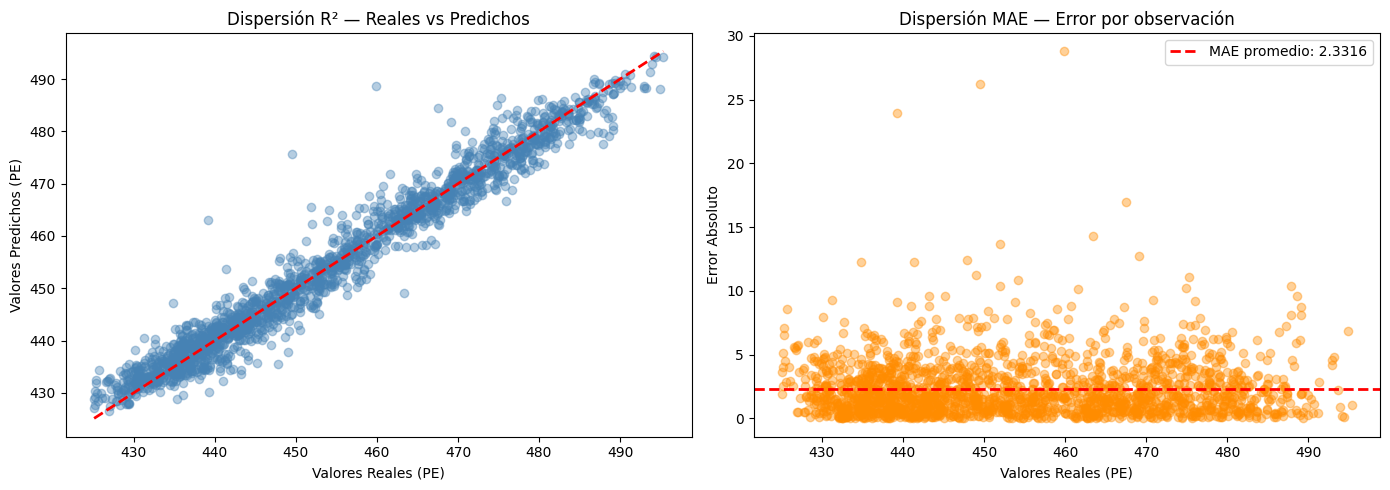

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

model_final = RandomForestRegressor(n_estimators=100, random_state=42)
model_final.fit(X_train, y_train)
y_pred = model_final.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R2 - Valores reales vs predichos
axes[0].scatter(y_test, y_pred, alpha=0.4, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
axes[0].set_xlabel('Valores Reales (PE)')
axes[0].set_ylabel('Valores Predichos (PE)')
axes[0].set_title('Dispersión R² — Reales vs Predichos')

# MAE - Error absoluto
errores = abs(y_test - y_pred)
axes[1].scatter(y_test, errores, alpha=0.4, color='darkorange')
axes[1].axhline(y=errores.mean(), color='r', linestyle='--', linewidth=2, label=f'MAE promedio: {errores.mean():.4f}')
axes[1].set_xlabel('Valores Reales (PE)')
axes[1].set_ylabel('Error Absoluto')
axes[1].set_title('Dispersión MAE — Error por observación')
axes[1].legend()

plt.tight_layout()
plt.show()

## 10. Exportar modelo y scaler

In [10]:
import joblib

joblib.dump(model_final, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print('model.pkl y scaler.pkl guardados')

model.pkl y scaler.pkl guardados
